In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import os
import time
import copy
import numpy as np

# GPU varsa kullan, yoksa CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Kullanılacak cihaz: {device}")

Kullanılacak cihaz: cpu


## 1. Gerekli Kütüphanelerin Yüklenmesi ve Donanım Yapılandırması

Bu bölümde, projenin çalışması için gerekli olan temel Python kütüphaneleri içe aktarılmaktadır. Derin öğrenme modelinin eğitimi, veri işleme ve görselleştirme süreçleri için şu araçlar kullanılacaktır:

* **PyTorch (`torch`, `torch.nn`, `torch.optim`):** Derin öğrenme modelinin mimarisini oluşturmak, eğitmek ve optimize etmek için kullanılan ana kütüphane.
* **Torchvision (`datasets`, `models`, `transforms`):** Görüntü işleme, veri artırma (augmentation) ve önceden eğitilmiş (pre-trained) ResNet50 modelini yüklemek için kullanılır.
* **Pandas (`pd`):** Veri setindeki etiketlerin bulunduğu CSV dosyalarını okumak ve işlemek için kullanılır.
* **PIL (`Image`) & Matplotlib (`plt`):** Görüntü dosyalarını açmak ve eğitim sonuçlarını (Loss/Accuracy grafikleri) görselleştirmek için kullanılır.

**Cihaz Ayarı (Device Configuration):**
Kod bloğunun sonunda, sistemde **CUDA** destekli bir GPU (Ekran Kartı) olup olmadığı kontrol edilir.
* Eğer GPU varsa, model eğitimi GPU üzerinde yapılarak işlem süresi **ciddi oranda kısaltılır**.
* GPU yoksa işlemci (CPU) kullanılır.

In [43]:
class RetinalDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.annotations = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, index):
        # 1. Sütun Resim ID'si, 2. Sütun Hastalık Riski (0 veya 1)
        img_id = str(self.annotations.iloc[index, 0])
        
        # Eğer CSV'de uzantı yoksa .png ekle
        if not img_id.endswith('.png'):
            img_id = img_id + '.png'
            
        img_path = os.path.join(self.root_dir, img_id)
        image = Image.open(img_path).convert("RGB")
        
        # Etiketi al (2. Sütun varsayılıyor: Disease_Risk)
        y_label = torch.tensor(int(self.annotations.iloc[index, 1]))

        if self.transform:
            image = self.transform(image)

        return image, y_label

## 2. Özel Veri Seti Sınıfının Oluşturulması (Custom Dataset Class)

Bu hücrede, PyTorch'un standart `Dataset` sınıfından türetilen **`RetinalDataset`** adında özel bir sınıf tanımlanmaktadır. Veri setimizdeki resimler klasörlere ayrılmamış olduğu ve etiket bilgileri (hastalık durumu) ayrı bir **CSV dosyasında** tutulduğu için bu özel yapıya ihtiyaç duyulmuştur.

Bu sınıfın üç temel fonksiyonu vardır:

1.  **`__init__` (Başlatıcı):** Veri setinin bulunduğu klasör yolunu ve etiketlerin olduğu CSV dosyasını (`pandas` kullanarak) okur. Ayrıca görüntü dönüşümlerini (transform) tanımlar.
2.  **`__len__` (Uzunluk):** Veri setinde toplam kaç adet resim olduğunu döndürür.
3.  **`__getitem__` (Veri Getirici):** Eğitim sırasında en çok çalışan fonksiyondur. Belirtilen indeksteki (`index`) resim dosyasını diskten bulur, okur ve RGB formatına çevirir. Aynı zamanda CSV dosyasının ilgili satırından hastalık etiketini (`0` veya `1`) alarak görüntüyle birlikte bir **PyTorch tensörü** olarak döndürür.

In [33]:
# --- SENİN VERDİĞİN DOSYA YOLLARI ---
train_img_dir  = r"C:\Users\berka\OneDrive\Masaüstü\arşiv\archive (2)\Training_Set\Training_Set\Training"
train_csv_path = r"C:\Users\berka\OneDrive\Masaüstü\arşiv\archive (2)\Training_Set\Training_Set\RFMiD_Training_Labels.csv"

val_img_dir    = r"C:\Users\berka\OneDrive\Masaüstü\arşiv\archive (2)\Evaluation_Set\Evaluation_Set\Validation"
val_csv_path   = r"C:\Users\berka\OneDrive\Masaüstü\arşiv\archive (2)\Evaluation_Set\Evaluation_Set\RFMiD_Validation_Labels.csv"

test_img_dir   = r"C:\Users\berka\OneDrive\Masaüstü\arşiv\archive (2)\Test_Set\Test_Set\Test"
test_csv_path  = r"C:\Users\berka\OneDrive\Masaüstü\arşiv\archive (2)\Test_Set\Test_Set\RFMiD_Testing_Labels.csv"
# ------------------------------------

# Veri Dönüşümleri
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

print("Veriler yükleniyor...")

# Datasetleri oluştur
train_dataset = RetinalDataset(csv_file=train_csv_path, root_dir=train_img_dir, transform=data_transforms['train'])
val_dataset   = RetinalDataset(csv_file=val_csv_path, root_dir=val_img_dir, transform=data_transforms['val'])
test_dataset  = RetinalDataset(csv_file=test_csv_path, root_dir=test_img_dir, transform=data_transforms['val'])

# Loaderları oluştur
dataloaders = {
    'train': DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0),
    'val':   DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0),
    'test':  DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)
}

dataset_sizes = {'train': len(train_dataset), 'val': len(val_dataset), 'test': len(test_dataset)}

# Sınıf sayısını otomatik bul
df = pd.read_csv(train_csv_path)
num_classes = df.iloc[:, 1].nunique()

print(f"BAŞARILI: Veriler yüklendi.")
print(f"Eğitim Sayısı: {dataset_sizes['train']}")
print(f"Sınıf Sayısı: {num_classes}")

Veriler yükleniyor...
BAŞARILI: Veriler yüklendi.
Eğitim Sayısı: 1920
Sınıf Sayısı: 2


## 3. Veri Yükleme, Ön İşleme ve Artırma (Data Loading & Augmentation)

Bu bölümde, ham veri setinin modele verilmeden önceki hazırlık aşamaları gerçekleştirilmektedir. İşlemler üç ana başlıkta toplanabilir:

1.  **Dosya Yollarının Tanımlanması:** Eğitim (Train), Doğrulama (Validation) ve Test setleri için resim klasörleri ve etiketlerin bulunduğu CSV dosyalarının yolları sisteme tanıtılır.
2.  **Veri Dönüşümleri (Transforms & Augmentation):**
    * **Eğitim Seti İçin:** Modelin ezberlemesini (overfitting) önlemek ve genelleme yeteneğini artırmak amacıyla **Veri Artırma (Data Augmentation)** teknikleri uygulanır. Resimler rastgele yatay çevrilir (`RandomHorizontalFlip`) ve döndürülür (`RandomRotation`). Ayrıca tüm resimler, ResNet50 modelinin beklediği **224x224** boyutuna getirilir ve ImageNet veri setinin istatistiklerine göre normalize edilir.
    * **Doğrulama Seti İçin:** Sadece boyutlandırma ve normalizasyon işlemi yapılır; veri artırma teknikleri (döndürme vb.) uygulanmaz. Bu sayede modelin gerçek performansı saf veriler üzerinde test edilir.
3.  **DataLoader Oluşturma:**
    * Veriler, eğitim sürecini hızlandırmak için tek tek değil, **32'lik paketler (batch)** halinde modele sunulur.
    * Eğitim verisi her epoch başında karıştırılır (`shuffle=True`), ancak doğrulama ve test verileri sabit tutulur.

Son olarak, veri setindeki sınıf sayısı (hastalık türü sayısı) CSV dosyasından otomatik olarak hesaplanarak modelin çıkış katmanının dinamik olarak ayarlanması sağlanır.

In [34]:
print("Model indiriliyor...")
model_ft = models.resnet50(weights='IMAGENET1K_V1')

# Son katmanı bizim sınıf sayımıza göre ayarla
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, num_classes)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_ft = optim.Adam(model_ft.parameters(), lr=0.001)

print("Model hazır.")

Model indiriliyor...
Model hazır.


## 4. Model Mimarisi ve Transfer Öğrenme (Model Architecture & Transfer Learning)

Bu bölümde, görüntü sınıflandırma problemlerinde endüstri standardı olan **ResNet50** mimarisi kullanılmaktadır. Modelin kurulumu şu aşamalardan oluşur:

1.  **Ön Eğitimli Modelin Yüklenmesi (Pre-trained Model):**
    * `models.resnet50(weights='IMAGENET1K_V1')` komutu ile, 1000 farklı nesne sınıfını içeren devasa **ImageNet** veri seti üzerinde önceden eğitilmiş ağırlıklar yüklenir.
    * Bu sayede model; kenar, köşe, doku gibi temel görsel özellikleri zaten öğrenmiş olarak başlar. Bu yöntem, eğitim süresini kısaltır ve daha az veri ile daha yüksek başarı sağlar.

2.  **Çıkış Katmanının Özelleştirilmesi (Fine-Tuning):**
    * ResNet50'nin orijinal son katmanı 1000 sınıflı çıktı verir. Ancak bizim veri setimizde sadece `num_classes` (örneğin 2: Hasta/Sağlıklı) kadar sınıf vardır.
    * Bu nedenle modelin son tam bağlantılı katmanı (`fc`), bizim sınıf sayımıza uygun yeni bir katmanla (`nn.Linear`) değiştirilir.

3.  **Kayıp Fonksiyonu ve Optimizasyon:**
    * **Kayıp Fonksiyonu (`CrossEntropyLoss`):** Modelin tahminleri ile gerçek etiketler arasındaki hatayı hesaplar. Sınıflandırma problemleri için standarttır.
    * **Optimizasyon (`Adam`):** Hesaplanan hataya göre modelin ağırlıklarını güncelleyen algoritmadır. Öğrenme oranı (`lr=0.001`) ile modelin ne kadar hızlı öğreneceği belirlenir.

In [35]:
def train_model(model, criterion, optimizer, num_epochs=10):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
        print()

    time_elapsed = time.time() - since
    print(f'Eğitim bitti: {time_elapsed // 60:.0f}dk {time_elapsed % 60:.0f}sn')
    print(f'En iyi Val Acc: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)
    return model, history

## 5. Modelin Eğitimi ve Doğrulama Döngüsü (Training & Validation Loop)

Bu hücrede tanımlanan `train_model` fonksiyonu, derin öğrenme sürecinin kalbini oluşturur. Belirlenen tur sayısı (**Epoch**) boyunca model hem eğitilir hem de performansı test edilir. Fonksiyonun çalışma mantığı şu adımlardan oluşur:

1.  **Eğitim ve Doğrulama Fazları:**
    * Her epoch içinde iki aşama vardır: `'train'` (Eğitim) ve `'val'` (Doğrulama).
    * **Train Fazı:** Model `model.train()` moduna alınır. Gradyanlar hesaplanır ve **Geri Yayılım (Backpropagation)** ile modelin ağırlıkları güncellenir. Yani model bu aşamada "öğrenir".
    * **Validation Fazı:** Model `model.eval()` moduna alınır. Ağırlık güncellemesi **yapılmaz**. Amaç, modelin o ana kadar ne kadar iyi öğrendiğini, hiç görmediği verilerle test etmektir.

2.  **Kayıp ve Doğruluk Hesabı:**
    * Her adımda modelin tahmini ile gerçek etiket arasındaki hata (**Loss**) ve doğru tahmin oranı (**Accuracy**) hesaplanır.
    * Bu veriler `history` sözlüğünde saklanarak eğitim sonunda grafik çizimi için kullanılır.

3.  **En İyi Modelin Saklanması (Checkpointing):**
    * Eğitim sırasında model bazen ezberlemeye (overfitting) başlayabilir ve performansı düşebilir.
    * Bunu önlemek için kod, her epoch sonunda **Doğrulama Başarısını (Val Acc)** kontrol eder. Eğer o anki başarı, şimdiye kadarki en iyi başarıdan yüksekse, modelin ağırlıkları kopyalanır (`best_model_wts`).
    * Fonksiyon sonunda, son epoch'taki model değil, **en yüksek başarıyı veren model** geri döndürülür.

In [36]:
NUM_EPOCHS = 15
print("Eğitim başlıyor...")
model_trained, history = train_model(model_ft, criterion, optimizer_ft, num_epochs=NUM_EPOCHS)

Eğitim başlıyor...
Epoch 1/15
----------
train Loss: 0.4604 Acc: 0.7953
val Loss: 0.7096 Acc: 0.6016

Epoch 2/15
----------
train Loss: 0.4223 Acc: 0.8234
val Loss: 0.4172 Acc: 0.8016

Epoch 3/15
----------
train Loss: 0.3978 Acc: 0.8229
val Loss: 0.3519 Acc: 0.8484

Epoch 4/15
----------
train Loss: 0.3820 Acc: 0.8271
val Loss: 0.3274 Acc: 0.8594

Epoch 5/15
----------
train Loss: 0.3489 Acc: 0.8385
val Loss: 0.6515 Acc: 0.7031

Epoch 6/15
----------
train Loss: 0.3533 Acc: 0.8333
val Loss: 0.4208 Acc: 0.8187

Epoch 7/15
----------
train Loss: 0.3440 Acc: 0.8505
val Loss: 0.3363 Acc: 0.8656

Epoch 8/15
----------
train Loss: 0.3156 Acc: 0.8490
val Loss: 0.3324 Acc: 0.8484

Epoch 9/15
----------
train Loss: 0.3103 Acc: 0.8589
val Loss: 0.3021 Acc: 0.8406

Epoch 10/15
----------
train Loss: 0.2967 Acc: 0.8604
val Loss: 0.3476 Acc: 0.8688

Epoch 11/15
----------
train Loss: 0.2879 Acc: 0.8641
val Loss: 0.2925 Acc: 0.8547

Epoch 12/15
----------
train Loss: 0.2951 Acc: 0.8594
val Loss: 0.

## 6. Eğitimin Başlatılması (Execution of Training)

Bu hücrede, tanımlanan parametrelerle eğitim süreci resmen başlatılır.

* **Hiperparametre Ayarı (`NUM_EPOCHS = 15`):** Modelin tüm eğitim veri setini kaç kez baştan sona tarayacağı belirlenir. 15 epoch, genellikle transfer öğrenme projelerinde modelin öğrenmesi için yeterli bir başlangıç noktasıdır.
* **Sürecin İşleyişi:** Kod çalıştırıldığında, model her epoch sonunda eğitim ve doğrulama kayıplarını ekrana yazdırır. Bu işlem, kullanılan donanıma (GPU/CPU) bağlı olarak birkaç dakika ile saatler arasında sürebilir.
* **Çıktılar:** Eğitim tamamlandığında, `model_trained` değişkeni **en yüksek doğrulama başarısına** sahip modelin ağırlıklarını taşırken; `history` değişkeni, ileride grafik çizdirmek için kullanacağımız kayıp (loss) ve doğruluk (accuracy) verilerini tutar.

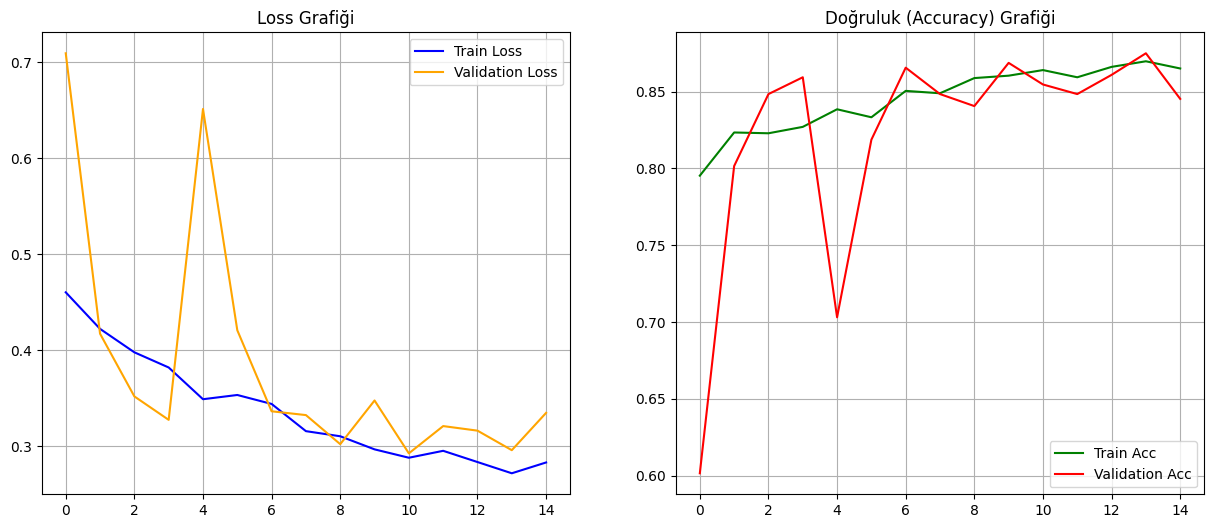

In [37]:
def plot_results(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    ax1.plot(history['train_loss'], label='Train Loss', color='blue')
    ax1.plot(history['val_loss'], label='Validation Loss', color='orange')
    ax1.set_title('Loss Grafiği')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(history['train_acc'], label='Train Acc', color='green')
    ax2.plot(history['val_acc'], label='Validation Acc', color='red')
    ax2.set_title('Doğruluk (Accuracy) Grafiği')
    ax2.legend()
    ax2.grid(True)
    plt.show()

plot_results(history)

## 7. Eğitim Sonuçlarının Görselleştirilmesi (Visualizing Training Results)

Eğitim tamamlandıktan sonra, modelin performansını analiz etmek için `history` değişkeninde saklanan veriler görselleştirilir. Bu hücrede oluşturulan iki grafik, modelin başarısını yorumlamak için kullanılır:

1.  **Kayıp Grafiği (Loss Graph - Sol Taraf):**
    * **Mavi Çizgi (Train Loss):** Modelin eğitim verisi üzerindeki hatasını gösterir. Beklenen durum, bu çizginin sürekli düşmesidir.
    * **Turuncu Çizgi (Validation Loss):** Modelin hiç görmediği doğrulama verisi üzerindeki hatasını gösterir.
    * **Yorum:** İdeal durumda iki çizgi de paralel olarak aşağı inmelidir. Eğer mavi çizgi düşerken turuncu çizgi yükselmeye başlarsa, model **ezberlemeye (overfitting)** başlamış demektir.

2.  **Doğruluk Grafiği (Accuracy Graph - Sağ Taraf):**
    * **Yeşil Çizgi (Train Acc):** Modelin eğitim verisini ne kadar doğru bildiğini gösterir.
    * **Kırmızı Çizgi (Validation Acc):** Modelin doğrulama verisindeki başarısını gösterir.
    * **Yorum:** Her iki çizginin de yükselmesi ve birbirine yakın seyretmesi modelin sağlıklı öğrendiğini ve genelleme yapabildiğini gösterir.

Test seti değerlendiriliyor...


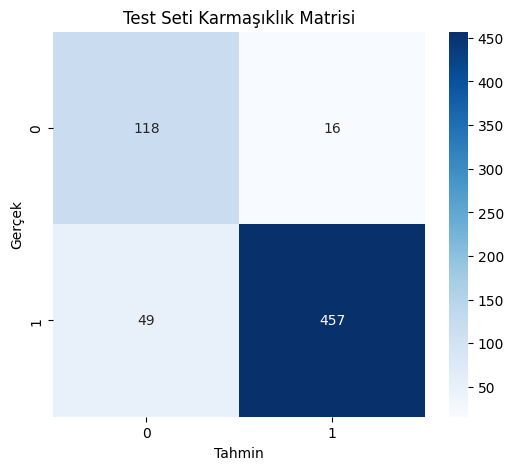

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def evaluate_test_set(model):
    model.eval()
    all_preds = []
    all_labels = []
    
    print("Test seti değerlendiriliyor...")
    with torch.no_grad():
        for inputs, labels in dataloaders['test']:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Test Seti Karmaşıklık Matrisi')
    plt.xlabel('Tahmin')
    plt.ylabel('Gerçek')
    plt.show()

evaluate_test_set(model_trained)

## 8. Test Seti ile Nihai Değerlendirme ve Karmaşıklık Matrisi (Test Set Evaluation & Confusion Matrix)

Eğitim ve doğrulama süreçleri tamamlandıktan sonra, modelin gerçek dünya performansını ölçmek için bu adım uygulanır. Buradaki veriler (`Test Set`), modele eğitim boyunca **hiç gösterilmemiştir**.

Bu hücrenin iki temel çıktısı vardır:
1.  **Tahminlerin Toplanması:** `model.eval()` ve `torch.no_grad()` komutları ile model öğrenme modundan çıkarılır. Test setindeki tüm görüntüler modele verilir ve sonuçlar toplanır.
2.  **Karmaşıklık Matrisi (Confusion Matrix):** Modelin başarısını detaylı analiz etmek için kullanılır. Sadece "Doğruluk" oranına bakmak yerine, modelin hangi sınıfları birbirine karıştırdığını gösterir.
    * **Y-Ekseni (Gerçek):** Resmin gerçek etiketi.
    * **X-Ekseni (Tahmin):** Modelin tahmin ettiği etiket.
    * **Yorumlama:** Matrisin sol üstten sağ alta giden köşegeni (diagonal) üzerindeki sayılar **doğru tahminleri** gösterir. Köşegen dışındaki sayılar ise modelin yaptığı hataları (örneğin; Hasta olan birine Sağlıklı demesi gibi) ifade eder.

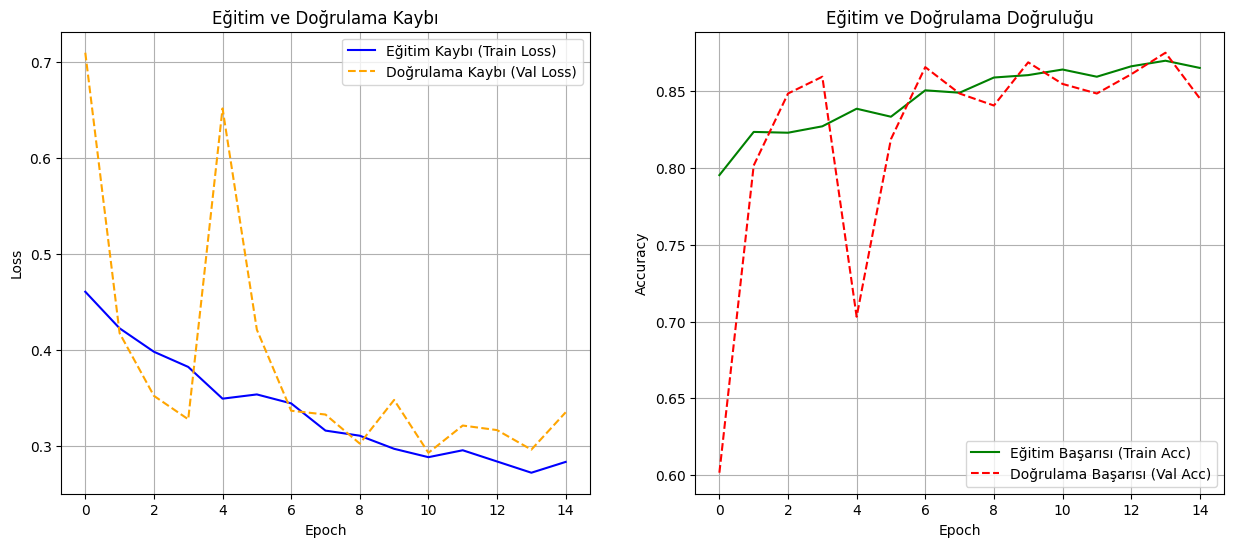

In [39]:
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # 1. Grafik: Kayıp (Loss)
    ax1.plot(history['train_loss'], label='Eğitim Kaybı (Train Loss)', color='blue', linestyle='-')
    ax1.plot(history['val_loss'], label='Doğrulama Kaybı (Val Loss)', color='orange', linestyle='--')
    ax1.set_title('Eğitim ve Doğrulama Kaybı')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # 2. Grafik: Doğruluk (Accuracy)
    ax2.plot(history['train_acc'], label='Eğitim Başarısı (Train Acc)', color='green', linestyle='-')
    ax2.plot(history['val_acc'], label='Doğrulama Başarısı (Val Acc)', color='red', linestyle='--')
    ax2.set_title('Eğitim ve Doğrulama Doğruluğu')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.show()

# Grafiği çiz
plot_training_history(history)

## 9. Eğitim Sürecinin Grafiksel Analizi (Visualizing Training History)

Bu hücrede, `train_model` fonksiyonundan dönen `history` değişkeni kullanılarak modelin epochlar boyunca sergilediği performans görselleştirilir. İki ayrı grafik çizilir:

1.  **Kayıp Grafiği (Loss Graph - Sol Taraf):**
    * Modelin tahminleri ile gerçek değerler arasındaki hatayı gösterir.
    * **Mavi Çizgi (Train):** Modelin eğitim verisindeki hatasıdır. Sürekli düşmesi beklenir.
    * **Turuncu Çizgi (Validation):** Modelin görmediği verilerdeki hatasıdır.
    * *Kritik Nokta:* Eğer Mavi çizgi düşerken Turuncu çizgi yükselmeye başlarsa, bu **Aşırı Öğrenme (Overfitting)** belirtisidir; model ezberlemeye başlamış demektir.

2.  **Doğruluk Grafiği (Accuracy Graph - Sağ Taraf):**
    * Modelin ne kadar doğru tahmin yaptığını gösterir (Örn: %85).
    * **Yeşil Çizgi (Train):** Eğitim başarısı.
    * **Kırmızı Çizgi (Validation):** Doğrulama başarısı.
    * İdeal senaryoda her iki çizgi de paralel bir şekilde yükselip belirli bir noktada doyuma ulaşmalıdır.

Test seti üzerinde detaylı analiz yapılıyor...

MODEL PERFORMANS RAPORU
✅ Doğruluk (Accuracy):  %89.84
⚖️ F1 Skoru (Weighted):  0.9023
📈 ROC AUC Değeri:       0.9585

Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.71      0.88      0.78       134
           1       0.97      0.90      0.93       506

    accuracy                           0.90       640
   macro avg       0.84      0.89      0.86       640
weighted avg       0.91      0.90      0.90       640



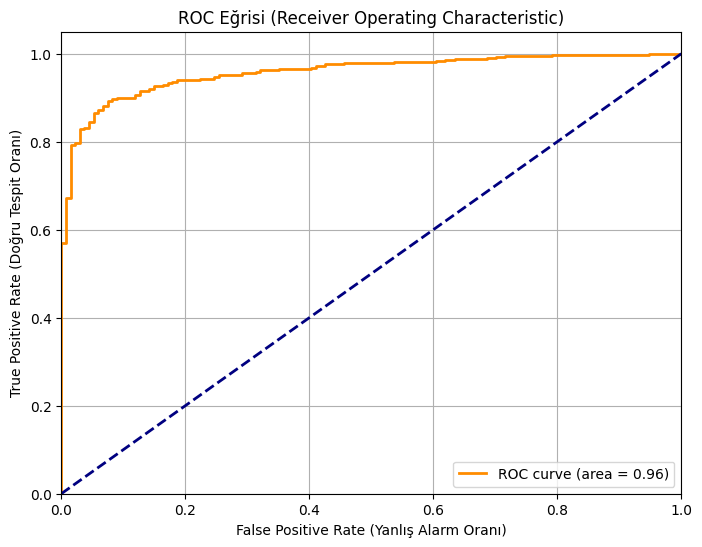

In [44]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, classification_report
import torch.nn.functional as F

def evaluate_detailed_metrics(model, dataloader):
    model.eval() # Modeli değerlendirme moduna al
    
    y_true = []   # Gerçek etiketler
    y_pred = []   # Modelin tahmin ettiği sınıflar (0 veya 1)
    y_probs = []  # Modelin verdiği olasılık değeri (ROC AUC için gerekli)

    print("Test seti üzerinde detaylı analiz yapılıyor...")

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Model çıktısını al
            outputs = model(inputs)
            
            # ROC AUC için olasılıklara (probability) ihtiyacımız var. 
            # Logitleri 0-1 arasına çekmek için Softmax uyguluyoruz.
            probs = F.softmax(outputs, dim=1)
            
            # En yüksek olasılıklı sınıfı seç (Prediction)
            _, preds = torch.max(outputs, 1)

            # Listelere ekle
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            
            # İkili sınıflandırma varsayımıyla Pozitif sınıfın (Sınıf 1 - Hastalık) olasılığını alıyoruz
            # Eğer model çok sınıflıysa burası değişebilir, şu an Disease Risk (Var/Yok) için 1. indeksi alıyoruz.
            y_probs.extend(probs[:, 1].cpu().numpy())

    # --- METRİKLERİ HESAPLA ---
    
    # 1. Doğruluk (Accuracy)
    acc = accuracy_score(y_true, y_pred)
    
    # 2. F1 Skoru (Dengesiz veri setleri için kritiktir)
    # 'weighted': Sınıf dengesizliğini hesaba katar.
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    # 3. ROC AUC Skoru
    try:
        auc = roc_auc_score(y_true, y_probs)
    except ValueError:
        auc = 0.0
        print("Uyarı: ROC AUC hesaplanamadı (Tek sınıf tahmin edilmiş olabilir).")

    # --- SONUÇLARI YAZDIR ---
    print("\n" + "="*30)
    print("MODEL PERFORMANS RAPORU")
    print("="*30)
    print(f"✅ Doğruluk (Accuracy):  %{acc*100:.2f}")
    print(f"⚖️ F1 Skoru (Weighted):  {f1:.4f}")
    print(f"📈 ROC AUC Değeri:       {auc:.4f}")
    print("="*30)
    
    # Sınıf bazlı detaylı rapor
    print("\nDetaylı Sınıflandırma Raporu:")
    print(classification_report(y_true, y_pred))

    # --- ROC EĞRİSİ ÇİZİMİ ---
    if auc > 0:
        fpr, tpr, thresholds = roc_curve(y_true, y_probs)
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Rastgele tahmin çizgisi
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate (Yanlış Alarm Oranı)')
        plt.ylabel('True Positive Rate (Doğru Tespit Oranı)')
        plt.title('ROC Eğrisi (Receiver Operating Characteristic)')
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.show()

# Fonksiyonu çalıştır (Test setini kullanıyoruz)
evaluate_detailed_metrics(model_trained, dataloaders['test'])

## 10. Detaylı Performans Analizi: F1 Skoru ve ROC Eğrisi (Detailed Metrics & ROC Curve)

Tıbbi görüntü sınıflandırma projelerinde, veri setleri genellikle dengesizdir (örneğin; çok fazla sağlıklı, az sayıda hasta görüntüsü olabilir). Bu durumda model, herkese "Sağlıklı" diyerek yüksek doğruluk (Accuracy) elde edebilir ancak hastaları tespit edemez. Bu yanılgıya düşmemek için bu hücrede **profesyonel performans metrikleri** hesaplanmaktadır:

1.  **F1 Skoru (Weighted):** Kesinlik (Precision) ve Duyarlılık (Recall) değerlerinin harmonik ortalamasıdır. Dengesiz veri setlerinde modelin ne kadar dengeli öğrendiğini gösteren en kritik değerdir.
2.  **ROC AUC Skoru:** Modelin "Hasta" ve "Sağlıklı" sınıflarını birbirinden ne kadar iyi ayırabildiğini (ayırt etme gücünü) gösterir. 0.5 değeri rastgele tahmini, 1.0 değeri mükemmel ayrımı ifade eder.
3.  **ROC Eğrisi (Receiver Operating Characteristic Curve):** Modelin başarısını görselleştiren bir grafiktir. Eğri, sol üst köşeye ne kadar yakınsa model o kadar başarılıdır.

**Kodun İşleyişi:**
* Modelin ham çıktıları (logits), **Softmax** fonksiyonu ile 0-1 arasında olasılık değerlerine dönüştürülür.
* `scikit-learn` kütüphanesi kullanılarak tahminler ve gerçek etiketler karşılaştırılır; Accuracy, F1 ve AUC değerleri hesaplanarak raporlanır.